In [1]:
import numpy as np
import pandas as pd
from sklearn import set_config
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# configure sklearn to work with panda df

set_config(transform_output="pandas")

In [4]:
penguins = pd.read_csv("dataset/penguins.csv")

penguins

,bill_length_mm,flipper_length_mm
0,39.1,181
1,39.5,186
2,40.3,195
3,36.7,193
4,39.3,190
...,...,...
337,55.8,207
338,43.5,202
339,49.6,193
340,50.8,210


In [6]:
penguins.agg(['min','max']) #Pull max and min values for each column

,bill_length_mm,flipper_length_mm
min,32.1,172
max,59.6,231


In [7]:
penguins_copy = penguins.copy() # make a copy of our dataset

In [9]:
scaler = StandardScaler()
standardized_penguins = scaler.fit_transform(penguins_copy)

standardized_penguins

,bill_length_mm,flipper_length_mm
0,-0.884499,-1.418347
1,-0.811126,-1.062250
2,-0.664380,-0.421277
3,-1.324737,-0.563715
4,-0.847812,-0.777373
...,...,...
337,2.178824,0.433355
338,-0.077396,0.077258
339,1.041543,-0.563715
340,1.261662,0.647013


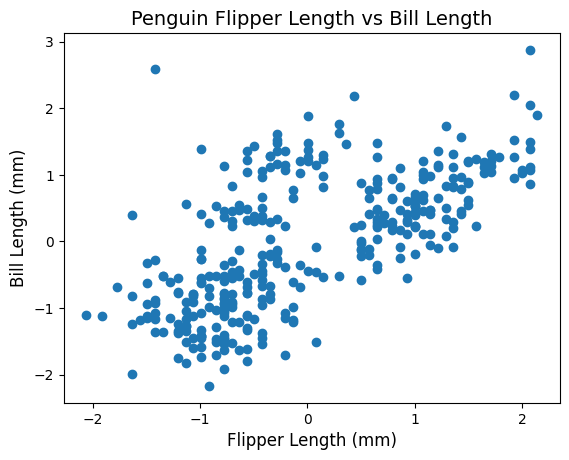

In [10]:
# Scatter plot for bill_length_mm vs flipper_length_mm
plt.scatter(standardized_penguins['flipper_length_mm'], standardized_penguins['bill_length_mm'])

# Adding labels and title
plt.title('Penguin Flipper Length vs Bill Length', fontsize=14)
plt.ylabel('Bill Length (mm)', fontsize=12)
plt.xlabel('Flipper Length (mm)', fontsize=12)

# Display the plot
plt.show()

In [11]:
# Perform K-means clustering
#Step 1 - Initialized our model
kmeans = KMeans(n_clusters=5, random_state=123, n_init=10)


In [12]:
#Step 2 - fit model to data
clusters = kmeans.fit(standardized_penguins)

In [13]:
clusters.labels_

array([1, 1, 4, 1, 1, 1, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1,
       1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 1, 1, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1,
       1, 1, 4, 1, 1, 1, 2, 1, 4, 1, 4, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 1, 1, 4, 1, 1, 1, 4, 1, 4, 1, 4, 1, 2, 1, 4, 1,
       1, 1, 4, 1, 4, 1, 1, 4, 1, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 2, 3, 2,
       3, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2,
       3, 2, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 2, 3, 2, 2, 3, 2, 3, 2, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 3, 3, 0, 3, 3, 3, 2, 3, 2, 2, 2, 3, 2, 2, 3, 3, 2,
       3, 2, 3, 2, 3, 2, 2, 3, 2, 3, 4, 0, 0, 4, 0, 4, 4, 0, 4, 0, 4, 0,
       4, 0, 4, 0, 0, 0, 4, 0, 4, 0, 4, 0, 4, 0, 0,

In [15]:
# Add cluster labels back to our dataset
standardized_penguins_with_clusters = standardized_penguins.copy()
standardized_penguins_with_clusters["Clusters"] = clusters.labels_
standardized_penguins_with_clusters

,bill_length_mm,flipper_length_mm,Clusters
0,-0.884499,-1.418347,1
1,-0.811126,-1.062250,1
2,-0.664380,-0.421277,4
3,-1.324737,-0.563715,1
4,-0.847812,-0.777373,1
...,...,...,...
337,2.178824,0.433355,0
338,-0.077396,0.077258,4
339,1.041543,-0.563715,0
340,1.261662,0.647013,0


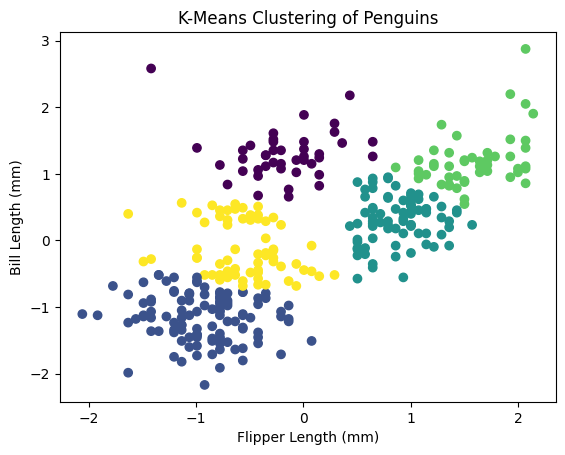

In [18]:
# Plot the clusters
plt.scatter(standardized_penguins_with_clusters['flipper_length_mm'], standardized_penguins_with_clusters['bill_length_mm'], c=standardized_penguins_with_clusters['Clusters'])
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Bill Length (mm)')
plt.title('K-Means Clustering of Penguins')
plt.show()

In [19]:
kmeans.inertia_  #total WSSD

91.47610853298528

In [ ]:
# Create an empty DataFrame to store the number of clusters (k) 
# and the corresponding within-cluster sum of squared distances (WSSD)
penguin_clust_ks = pd.DataFrame(columns=["k", "wssd"])

# Iterate over possible cluster counts from 1 to 10
for k in range(1, 11):
    # Initialize the K-means model with k clusters and a fixed random seed for reproducibility
    elbow_kmeans = KMeans(n_clusters=k, random_state=123)
    
    # Fit the model to the standardized penguin data
    elbow_kmeans.fit(standardized_penguins)
    
    # Store the current k value and the model's inertia (WSSD) in a temporary DataFrame
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    
    # Append the results for this k to the cumulative DataFrame
    penguin_clust_ks = pd.concat([penguin_clust_ks, current_k], ignore_index=True)

# Display the DataFrame
penguin_clust_ks

/var/folders/rz/q_ycy8wn56v66xqgsjqcc7540000gn/T/ipykernel_2105/3608820400.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  penguin_clust_ks = pd.concat([penguin_clust_ks, current_k], ignore_index=True)


,k,wssd
0,1,684.000000
1,2,247.016625
2,3,157.815322
3,4,128.451298
4,5,94.061233
5,6,79.419564
6,7,69.965331
7,8,60.616734
8,9,55.030936
9,10,52.111475


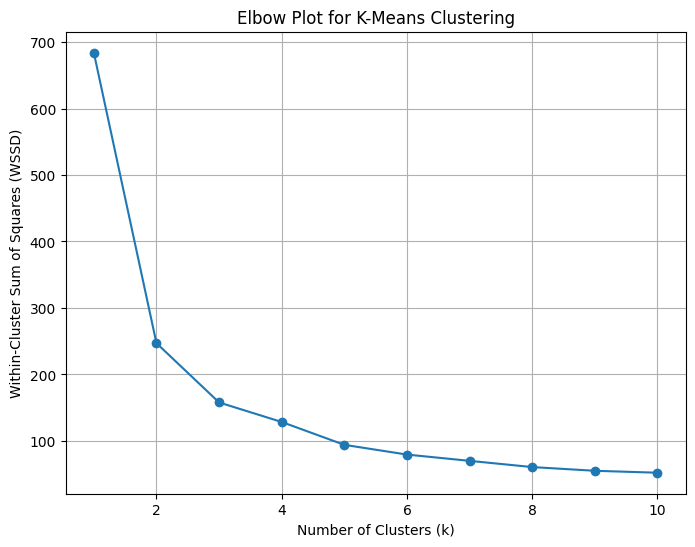

In [22]:
# Create the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(penguin_clust_ks['k'], penguin_clust_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True)
plt.show()